In [7]:
pip install tensorflow librosa numpy matplotlib scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [8]:
import os
import glob
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- PATHS ---
# Make sure this points to your dataset
DATASET_PATH = r"../data/raw/Audio/Baby Cry Dataset/" 
OUTPUT_PATH = r"../data/processed/"

# --- AUDIO SETTINGS ---
SAMPLE_RATE = 22050
DURATION = 5.0 # Seconds
SAMPLES = int(SAMPLE_RATE * DURATION) # 110,250 samples
N_MELS = 128
TIME_STEPS = 216 # Fixed width for 5s audio

# --- LABELS ---
# 0 = Hunger, 1 = Pain, 2 = Normal
LABEL_MAP = {
    'hungry': 0,
    'belly pain': 1, 'cold_hot': 1, 'discomfort': 1, 
    'tired': 2, 'burping': 2, 'lonely': 2, 'scared': 2
}

print("✅ Configuration Set. TensorFlow Version:", tf.__version__)

✅ Configuration Set. TensorFlow Version: 2.20.0


In [9]:
def audio_to_image(file_path):
    try:
        # 1. Load Audio (Force 5s)
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
        
        # 2. Pad or Truncate (Must be exactly 5s long)
        if len(y) < SAMPLES:
            y = np.pad(y, (0, SAMPLES - len(y))) 
        else:
            y = y[:SAMPLES] 
            
        # 3. Create Mel Spectrogram (The "Image")
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
        mel_db = librosa.power_to_db(mel, ref=np.max) # Convert to colors (dB)
        
        # 4. Fix Width (Must be exactly 216 pixels wide)
        if mel_db.shape[1] < TIME_STEPS:
            mel_db = np.pad(mel_db, ((0, 0), (0, TIME_STEPS - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :TIME_STEPS]
            
        # 5. Add "Channel" Dimension (Required for CNN input)
        # Shape becomes (128, 216, 1) -> Grayscale Image
        return mel_db[..., np.newaxis] 
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

print("✅ Function ready.")

✅ Function ready.


In [10]:
X_data = []
y_data = []

print("📸 Starting Visual Data Processing...")

for folder_name, label in LABEL_MAP.items():
    folder_path = os.path.join(DATASET_PATH, folder_name)
    files = glob.glob(os.path.join(folder_path, "*.wav"))
    
    print(f"   Processing {folder_name} (Class {label})... found {len(files)} files")
    
    for file in files:
        img = audio_to_image(file)
        if img is not None:
            # Add Original
            X_data.append(img)
            y_data.append(label)
            
            # --- AUGMENTATION (Balancing) ---
            # Duplicate 'Hunger' (0) and 'Normal' (2) to match 'Pain' (1)
            # (Assuming Pain has more files usually, adjust if needed)
            if label in [0, 2]: 
                X_data.append(img) # Simple copy to balance class size
                y_data.append(label) # Add the label for the duplicated image

X = np.array(X_data)
y = np.array(y_data)

# Normalize Data (0 to 1 scale is best for Neural Networks)
X = (X - X.min()) / (X.max() - X.min())

# One-Hot Encode Labels (e.g., 0 becomes [1, 0, 0])
y_onehot = to_categorical(y, num_classes=3)

print(f"\n✅ Processing Complete!")
print(f"Input Shape: {X.shape}") # Should be (N, 128, 216, 1)
print(f"Labels Shape: {y_onehot.shape}")

📸 Starting Visual Data Processing...
   Processing hungry (Class 0)... found 382 files
   Processing belly pain (Class 1)... found 126 files
   Processing cold_hot (Class 1)... found 107 files
   Processing discomfort (Class 1)... found 138 files
   Processing tired (Class 2)... found 136 files
   Processing burping (Class 2)... found 118 files
   Processing lonely (Class 2)... found 11 files
   Processing scared (Class 2)... found 20 files

✅ Processing Complete!
Input Shape: (1705, 128, 216, 1)
Labels Shape: (1705, 3)


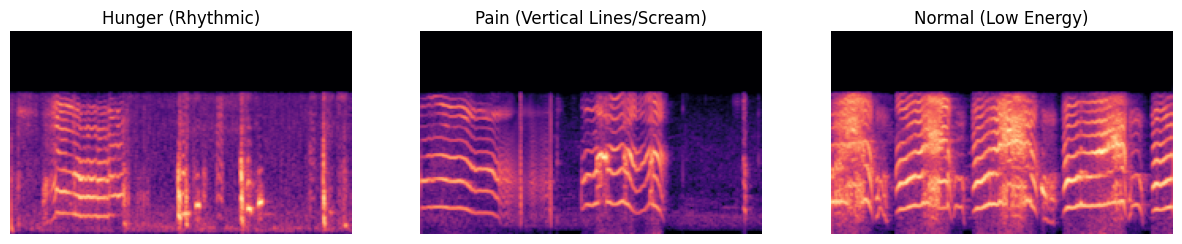

In [11]:
# Find indices for each class
idx_hunger = np.where(y == 0)[0][0]
idx_pain = np.where(y == 1)[0][0]
idx_normal = np.where(y == 2)[0][0]

plt.figure(figsize=(15, 5))

# Plot Hunger
plt.subplot(1, 3, 1)
plt.imshow(X[idx_hunger].squeeze(), cmap='magma', origin='lower')
plt.title("Hunger (Rhythmic)")
plt.axis('off')

# Plot Pain
plt.subplot(1, 3, 2)
plt.imshow(X[idx_pain].squeeze(), cmap='magma', origin='lower')
plt.title("Pain (Vertical Lines/Scream)")
plt.axis('off')

# Plot Normal
plt.subplot(1, 3, 3)
plt.imshow(X[idx_normal].squeeze(), cmap='magma', origin='lower')
plt.title("Normal (Low Energy)")
plt.axis('off')

plt.show()

In [12]:
# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

model = Sequential([
    # Layer 1: Edge Detection
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 216, 1)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    
    # Layer 2: Shape Detection
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    
    # Layer 3: Complex Pattern Detection
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    
    # Flatten & Decide
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4), # Drop 40% of neurons to prevent memorization
    Dense(3, activation='softmax') # Output Layer (3 Classes)
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

f:\Research\Project\Final\infant-growth-monitoring-system\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 214, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 107, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 107, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 105, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 52, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 52, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 44800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,734,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,828,483 (22.23 MB)

 Trainable params: 5,828,035 (22.23 MB)

 Non-trainable params: 448 (1.75 KB)

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step
🏆 Test Accuracy: 26.10%


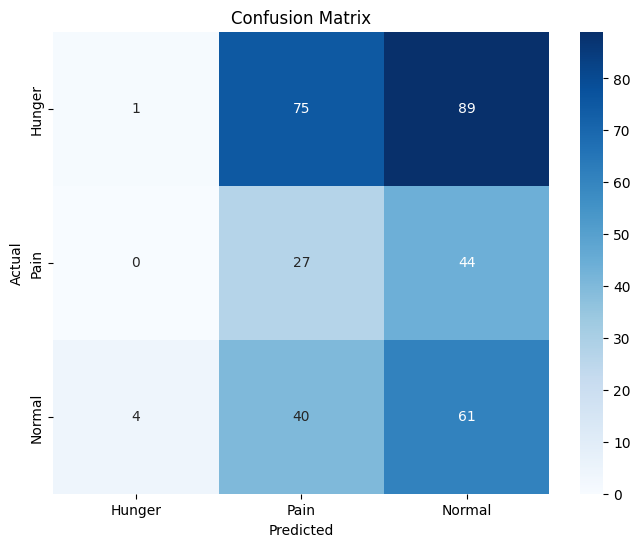

              precision    recall  f1-score   support

      Hunger       0.20      0.01      0.01       165
        Pain       0.19      0.38      0.25        71
      Normal       0.31      0.58      0.41       105

    accuracy                           0.26       341
   macro avg       0.23      0.32      0.22       341
weighted avg       0.23      0.26      0.18       341



In [13]:
# Get Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Accuracy
acc = np.sum(y_pred_classes == y_true) / len(y_true)
print(f"🏆 Test Accuracy: {acc:.2%}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Hunger', 'Pain', 'Normal'], 
            yticklabels=['Hunger', 'Pain', 'Normal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Detailed Report
print(classification_report(y_true, y_pred_classes, target_names=['Hunger', 'Pain', 'Normal']))

In [14]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
print("⏳ Loading Data...")
X = np.load("../data/processed/X_images.npy")
y = np.load("../data/processed/y_labels.npy")

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training on {len(X_train)} images, Testing on {len(X_test)}")

# --- CRITICAL FIX: Handle Class Imbalance ---
# This calculates how much "weight" to give each class.
# If "Pain" has few samples, the model will pay 2x or 3x more attention to it.
y_integers = np.argmax(y_train, axis=1)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_integers),
    y=y_integers
)
class_weight_dict = dict(enumerate(class_weights))
print(f"⚖️ Class Weights: {class_weight_dict}")

# 2. Build Optimized CNN (The "Lightweight" Brain)
model = Sequential([
    # Layer 1: Edges
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 216, 1)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    
    # Layer 2: Shapes
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    
    # Layer 3: Patterns
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    
    # --- THE FIX: GLOBAL AVERAGE POOLING ---
    # Instead of flattening (which creates millions of connections), 
    # we take the average of each feature map.
    # Params: 5,700,000 -> 0 (This layer has 0 params!)
    GlobalAveragePooling2D(), 
    
    # Dense Layers
    Dense(64, activation='relu'), # Reduced from 128
    Dropout(0.5), # Increased dropout to 50% to force learning
    Dense(3, activation='softmax')
])

# 3. Compile (Slower Learning Rate)
# 1e-3 is often too fast for small data. 1e-4 is safer.
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary() 
# Look at "Total params" now. It should be small (~30k-100k).

# 4. Train
print("\n🚀 Training CNN (Optimized)...")
history = model.fit(X_train, y_train, 
                    epochs=40, # Increased epochs since LR is lower
                    batch_size=32, 
                    validation_data=(X_test, y_test),
                    class_weight=class_weight_dict) # Apply weights

# 5. Evaluate
print("\n🏆 Final Evaluation:")
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=['Hunger', 'Pain', 'Normal']))

# 6. Save
save_path = "../saved_models/cnn_cry_model_v2.h5"
model.save(save_path)
print(f"💾 Model Saved to {save_path}")

⏳ Loading Data...
Training on 1364 images, Testing on 341
⚖️ Class Weights: {0: 0.7441352973267867, 1: 1.5308641975308641, 2: 0.9970760233918129}


f:\Research\Project\Final\infant-growth-monitoring-system\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 214, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 107, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 63, 107, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 105, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 52, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 52, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,019 (398.51 KB)

 Trainable params: 101,571 (396.76 KB)

 Non-trainable params: 448 (1.75 KB)


🚀 Training CNN (Optimized)...
Epoch 1/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 377ms/step - accuracy: 0.3314 - loss: 1.1356 - val_accuracy: 0.4487 - val_loss: 1.1042
Epoch 2/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 373ms/step - accuracy: 0.3754 - loss: 1.0846 - val_accuracy: 0.4487 - val_loss: 1.1195
Epoch 3/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 401ms/step - accuracy: 0.4128 - loss: 1.0521 - val_accuracy: 0.4487 - val_loss: 1.1265
Epoch 4/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 441ms/step - accuracy: 0.3959 - loss: 1.0547 - val_accuracy: 0.4487 - val_loss: 1.1225
Epoch 5/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 456ms/step - accuracy: 0.4084 - loss: 1.0411 - val_accuracy: 0.4487 - val_loss: 1.0806
Epoch 6/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 476ms/step - accuracy: 0.4289 - loss: 1.0318 - val_accuracy: 0.4604 - val_loss: 1.0463
Epoch 7/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 575ms/step - accuracy: 0.4216 - loss: 1.0242 - val_accuracy: 0.4809 - val_loss: 1.0415
Epoch 8/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 38s 506ms/step - accuracy: 0

              precision    recall  f1-score   support

      Hunger       0.47      0.31      0.37       153
        Pain       0.26      0.62      0.37        74
      Normal       0.61      0.36      0.45       114

    accuracy                           0.39       341
   macro avg       0.45      0.43      0.40       341
weighted avg       0.47      0.39      0.40       341

💾 Model Saved to ../saved_models/cnn_cry_model_v2.h5
